In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/PaddleDet-Models

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/17LXx-YpP2lamkZUgiY1A62xV8O46AQcz/PaddleDet-Models


In [2]:
!python --version

Python 3.12.13


In [3]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/sispanseg/train/images")
count_images("datasets/sispanseg/valid/images")

Total images: 200
Total images: 56


In [4]:
# Check train annotations
with open("datasets/sispanseg/train/instances_train_polygon.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/sispanseg/valid/instances_val_polygon.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 200
Train annotations: 296
Categories: [{'id': 1, 'name': 'Grasper', 'isthing': 1}, {'id': 2, 'name': 'Harmonic ACE', 'isthing': 1}, {'id': 3, 'name': 'Myoma Screw', 'isthing': 1}, {'id': 4, 'name': 'Needle Holder', 'isthing': 1}, {'id': 5, 'name': 'Trocer', 'isthing': 1}]

Valid images: 56
Valid annotations: 89


In [2]:
!git clone https://github.com/PaddlePaddle/PaddleDetection.git
%cd PaddleDetection

fatal: destination path 'PaddleDetection' already exists and is not an empty directory.
/content/gdrive/.shortcut-targets-by-id/17LXx-YpP2lamkZUgiY1A62xV8O46AQcz/PaddleDet-Models/PaddleDetection


In [6]:
!pip install paddlepaddle-gpu pyclipper attrdict gdown -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 71.1 MB/s eta 0:00:00


In [ ]:
# Force the "bridge" version of NumPy that works for both Python 3.12 and Paddle
!pip install numpy==1.26.4 --force-reinstall

# Re-install OpenCV without dependencies to stop it from fighting with NumPy
!pip install opencv-python-headless --no-deps --force-reinstall

In [3]:
!pip install -q -e .

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.5/443.5 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.0/417.0 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 20.5 MB/s eta 0:00:00


In [4]:
!python -c "import paddle; print(paddle.__version__); print(paddle.device.get_device()); import ppdet; print(ppdet.__version__)"

2.6.2
gpu:0
[05/19 11:50:26] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
0.0.0


In [5]:
!python ppdet/modeling/tests/test_architectures.py

[05/19 11:51:03] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0519 11:51:07.875923  3734 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0519 11:51:07.900044  3734 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
.......
----------------------------------------------------------------------
Ran 7 tests in 24.340s

OK


In [6]:
import json
import os

os.makedirs('dataset/coco/annotations', exist_ok=True)

COCO_CLASSES = ('person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
                'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
                'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
                'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
                'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
                'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
                'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
                'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
                'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
                'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
                'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
                'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
                'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
                'scissors', 'teddy bear', 'hair drier', 'toothbrush')

categories = []
for i, name in enumerate(COCO_CLASSES):
    categories.append({"id": i, "name": name, "supercategory": "none"})

dummy_data = {
    "images": [],
    "annotations": [],
    "categories": categories
}

with open('dataset/coco/annotations/instances_val2017.json', 'w') as f:
    json.dump(dummy_data, f)

print("Better dummy JSON created! Labels will now show real names.")

Better dummy JSON created! Labels will now show real names.


In [7]:
# !python tools/infer.py --help

In [8]:
!python tools/infer.py \
-c configs/rtdetrv2/rtdetrv2_r50vd_6x_coco.yml \
-o use_gpu=True \
weights=https://bj.bcebos.com/v1/paddledet/models/rtdetrv2_r50vd_6x_coco.pdparams \
--infer_img=/content/gdrive/MyDrive/PaddleDet-Models/datasets/panoptic-tests/room1.png \
--draw_threshold=0.3

[05/19 11:53:13] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0519 11:53:18.329399  4307 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0519 11:53:18.330423  4307 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/19 11:53:20] ppdet.utils.download INFO: Downloading rtdetrv2_r50vd_6x_coco.pdparams from https://bj.bcebos.com/v1/paddledet/models/rtdetrv2_r50vd_6x_coco.pdparams
100% 168120/168120 [00:04<00:00, 37141.46KB/s]
[05/19 11:53:27] ppdet.utils.checkpoint INFO: Finish loading model weights: /root/.cache/paddle/weights/rtdetrv2_r50vd_6x_coco.pdparams
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 1/1 [00:03<00:00,  3.18s/it]
[05/19 11:53:34] ppdet.engine INFO: Detection bbox results save in output/room1.png


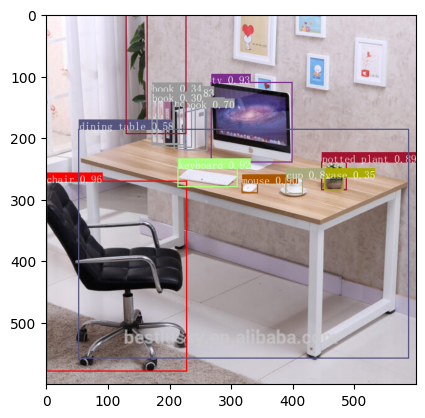

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/room1.png')

plt.figure("Image")
plt.imshow(img)
plt.show()

In [24]:
!ls configs/rtdetrv2/

_base_				rtdetrv2_r34vd_dsp_1x_coco.yml
README.md			rtdetrv2_r50vd_6x_coco.yml
rtdetrv2_r101vd_6x_coco.yml	rtdetrv2_r50vd_dsp_1x_coco.yml
rtdetrv2_r18vd_120e_coco.yml	rtdetrv2_r50vd_m_7x_coco.yml
rtdetrv2_r18vd_dsp_3x_coco.yml	rtdetrv2_r50vd_m_dsp_3x_coco.yml
rtdetrv2_r34vd_120e_coco.yml	rtdetrv2_sis.yml


In [17]:
200/4

50.0

In [25]:
custom_cfg = """
metric: COCO
num_classes: 5

TrainDataset:
  !COCODataSet
    image_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/images/
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/instances_train_polygon.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/
    data_fields: ['image', 'gt_bbox', 'gt_class', 'is_crowd']

EvalDataset:
  !COCODataSet
    image_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/instances_val_polygon.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/

TestDataset:
  !ImageFolder
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/instances_val_polygon.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/

worker_num: 4
TrainReader:
  sample_transforms:
    - Decode: {}
    - RandomDistort: {prob: 0.8}
    - RandomExpand: {fill_value: [123.675, 116.28, 103.53]}
    - RandomCrop: {prob: 0.8}
    - RandomFlip: {}
  batch_transforms:
    - BatchRandomResize: {target_size: [480, 512, 544, 576, 608, 640, 640, 640, 672, 704, 736, 768, 800], random_size: True, random_interp: True, keep_ratio: False}
    - NormalizeImage: {mean: [0., 0., 0.], std: [1., 1., 1.], norm_type: none}
    - NormalizeBox: {}
    - BboxXYXY2XYWH: {}
    - Permute: {}
  batch_size: 4
  shuffle: true
  drop_last: true
  collate_batch: false
  use_shared_memory: true

EvalReader:
  sample_transforms:
    - Decode: {}
    - Resize: {target_size: [640, 640], keep_ratio: False, interp: 2}
    - NormalizeImage: {mean: [0., 0., 0.], std: [1., 1., 1.], norm_type: none}
    - Permute: {}
  batch_size: 2
  shuffle: false
  drop_last: false

TestReader:
  inputs_def:
    image_shape: [3, 640, 640]
  sample_transforms:
    - Decode: {}
    - Resize: {target_size: [640, 640], keep_ratio: False, interp: 2}
    - NormalizeImage: {mean: [0., 0., 0.], std: [1., 1., 1.], norm_type: none}
    - Permute: {}
  batch_size: 2
  shuffle: false
  drop_last: false

architecture: DETR
pretrain_weights: https://bj.bcebos.com/v1/paddledet/models/rtdetrv2_r50vd_6x_coco.pdparams
norm_type: sync_bn
use_ema: True
ema_decay: 0.9999
ema_decay_type: "exponential"
ema_filter_no_grad: True
hidden_dim: 256
use_focal_loss: True
eval_size: [640, 640]
reset_norm_param_attr: True

DETR:
  backbone: ResNet
  neck: HybridEncoder
  transformer: RTDETRTransformerv2
  detr_head: DINOHead
  post_process: DETRPostProcess

ResNet:
  # index 0 stands for res2
  depth: 50
  variant: d
  norm_type: bn
  freeze_at: 0
  return_idx: [1, 2, 3]
  num_stages: 4
  freeze_norm: True

HybridEncoder:
  hidden_dim: 256
  use_encoder_idx: [2]
  num_encoder_layers: 1
  encoder_layer:
    name: TransformerLayer
    d_model: 256
    nhead: 8
    dim_feedforward: 1024
    dropout: 0.
    activation: 'gelu'
  expansion: 1.0

RTDETRTransformerv2:
  num_queries: 300
  position_embed_type: sine
  feat_strides: [8, 16, 32]
  num_levels: 3
  num_decoder_points: [4, 4, 4]
  nhead: 8
  num_decoder_layers: 6
  dim_feedforward: 1024
  dropout: 0.0
  activation: relu
  num_denoising: 100
  label_noise_ratio: 0.5
  box_noise_scale: 1.0
  learnt_init_query: False
  eval_idx: -1
  cross_attn_sampling_method: default

DINOHead:
  loss:
    name: DINOLoss
    loss_coeff: {class: 1, bbox: 5, giou: 2}
    aux_loss: True
    use_vfl: True
    matcher:
      name: HungarianMatcher
      matcher_coeff: {class: 2, bbox: 5, giou: 2}

DETRPostProcess:
  num_top_queries: 300

use_gpu: true
use_xpu: false
log_iter: 5
save_dir: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis
snapshot_epoch: 1
print_flops: false

# Exporting the model
export:
  post_process: True  # Whether post-processing is included in the network when export model.
  nms: True           # Whether NMS is included in the network when export model.
  benchmark: False    # It is used to testing model performance, if set `True`, post-process and NMS will not be exported.
  fuse_conv_bn: False

weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/model_final
find_unused_parameters: True

epoch: 20
LearningRate:
  base_lr: 0.0001
  schedulers:
  - !PiecewiseDecay
    gamma: 1.0
    milestones: [15, 19]
    use_warmup: true
  - !LinearWarmup
    start_factor: 0.001
    steps: 200

OptimizerBuilder:
  clip_grad_by_norm: 0.1
  regularizer: false
  optimizer:
    type: AdamW
    weight_decay: 0.0001
    param_groups:
      - params: ['^(?=.*backbone)(?!.*norm).*$']
        learning_rate: 0.00001
      - params: ['^(?=.*(?:neck|transformer))(?=.*(?:norm|bn)).*$']
        weight_decay: 0.
"""

with open('configs/rtdetrv2/rtdetrv2_sis.yml', 'w') as f:
    f.write(custom_cfg)

In [26]:
# usage: train.py [-h] [-c CONFIG] [-o [OPT ...]] [--eval] [-r RESUME]
#                 [--slim_config SLIM_CONFIG] [--enable_ce ENABLE_CE] [--amp]
#                 [--fleet] [--use_vdl USE_VDL] [--vdl_log_dir VDL_LOG_DIR]
#                 [--use_wandb USE_WANDB] [--save_prediction_only]
#                 [--profiler_options PROFILER_OPTIONS] [--save_proposals]
#                 [--proposals_path PROPOSALS_PATH] [--to_static]

In [27]:
!python tools/train.py \
-c configs/rtdetrv2/rtdetrv2_sis.yml \
-o use_gpu=True \
--eval

[05/19 12:05:03] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
[05/19 12:05:06] ppdet.data.source.coco INFO: Load [200 samples valid, 0 samples invalid] in file /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/instances_train_polygon.json.
W0519 12:05:06.414374  7371 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0519 12:05:06.415283  7371 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/19 12:05:09] ppdet.utils.checkpoint INFO: The shape [80] in pretrained weight transformer.dec_score_head.0.bias is unmatched with the shape [5] in model transformer.dec_score_head.0.bias. And the weight transformer.dec_score_head.0.bias will not be loaded
[05/19 12:05:09] ppdet.utils.checkpoint INFO: The shape [256, 80] in pretrained weight transformer.dec_score_head.0.weight is unmatched with 

In [28]:
!python tools/eval.py \
-c configs/rtdetrv2/rtdetrv2_sis.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/best_model \
-o use_gpu=True

[05/19 12:43:11] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0519 12:43:12.191875 36006 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0519 12:43:12.196488 36006 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
[05/19 12:43:13] ppdet.data.source.coco INFO: Load [56 samples valid, 0 samples invalid] in file /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/instances_val_polygon.json.
[05/19 12:43:14] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/model_final.pdparams
[05/19 12:43:15] ppdet.engine.callbacks INFO: Eval iter: 0
[05/19 12:43:19] ppdet.metrics.metrics INFO: The bbox result is saved to bbox.json.
loading annotations into memory...
Done (t=0.04s)
creating index...
index cr

In [29]:
!python tools/infer.py \
-c configs/rtdetrv2/rtdetrv2_sis.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/best_model \
-o use_gpu=True \
--infer_img=/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg \
--draw_threshold=0.3

[05/19 12:48:11] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0519 12:48:12.189908 37375 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0519 12:48:12.191238 37375 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/19 12:48:13] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/model_final.pdparams
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
100% 1/1 [00:00<00:00,  3.12it/s]
[05/19 12:48:14] ppdet.engine INFO: Detection bbox results save in output/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg


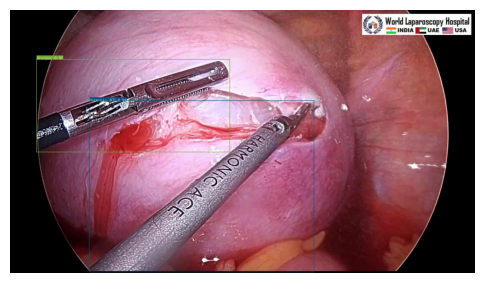

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg')

plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img)
plt.show()

In [33]:
!python tools/infer.py \
-c configs/rtdetrv2/rtdetrv2_sis.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/best_model \
-o use_gpu=True \
--infer_dir=/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/ \
--output_dir=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/infer_images/ \
--draw_threshold=0.3 \
--save_results=True

[05/19 12:54:25] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0519 12:54:26.207401 38981 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0519 12:54:26.208280 38981 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/19 12:54:28] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/model_final.pdparams
[05/19 12:54:28] train INFO: Found 56 inference images in total.
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
100% 28/28 [00:04<00:00,  6.57it/s]
[05/19 12:54:33] ppdet.metrics.metrics INFO: The bbox result is saved to bbox.json.
[05/19 12:54:33] ppdet.metrics.metrics INFO: The bbox res

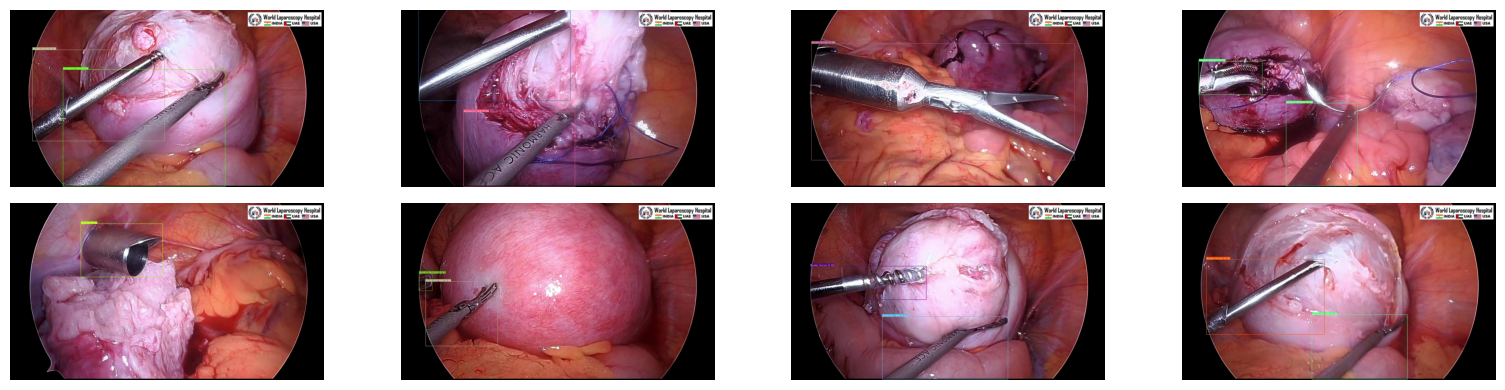

In [34]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import cv2
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/infer_images/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
!python tools/export_model.py \
-c configs/rtdetrv2/rtdetrv2_sis.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/best_model

[05/19 13:07:02] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
[05/19 13:07:05] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/best_model.pdparams
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
[05/19 13:07:31] ppdet.engine INFO: Export inference config file to output_inference/rtdetrv2_sis/infer_cfg.yml
[05/19 13:07:31] ppdet.engine INFO: Skipping import of the encryption module.
I0519 13:07:34.155231 42206 program_interpreter.cc:212] New Executor is Running.
[05/19 13:07:35] ppdet.engine INFO: Export model and saved in output_inference/rtdetrv2_sis


In [36]:
!pip install onnx onnxscript paddle2onnx==1.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 14.1 MB/s eta 0:00:00


In [37]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 6.1 MB/s eta 0:00:00


In [38]:
!paddle2onnx --model_dir=./output_inference/rtdetrv2_sis/ \
            --model_filename model.pdmodel  \
            --params_filename model.pdiparams \
            --opset_version 16 \
            --save_file /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/rtdetrv2_sis.onnx

[Paddle2ONNX] Start to parse PaddlePaddle model...
[Paddle2ONNX] Model file path: ./output_inference/rtdetrv2_sis/model.pdmodel
[Paddle2ONNX] Paramters file path: ./output_inference/rtdetrv2_sis/model.pdiparams
[Paddle2ONNX] Start to parsing Paddle model...
[Paddle2ONNX] Use opset_version = 16 for ONNX export.
[Paddle2ONNX] PaddlePaddle model is exported as ONNX format now.
2026-05-19 13:09:08 [INFO]	===============Make PaddlePaddle Better!================
2026-05-19 13:09:08 [INFO]	A little survey: https://iwenjuan.baidu.com/?code=r8hu2s


In [45]:
%ls /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/

best_model/          best_model.pdstates  model_final.pdparams
best_model.pdema     infer_images/        model_final.pdstates
best_model.pdopt     model_final.pdema    rtdetrv2_sis.onnx
best_model.pdparams  model_final.pdopt


In [46]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg"

img = cv2.imread(img_path)
orig_h, orig_w = img.shape[:2] # Get original dimensions
img_resized = cv2.resize(img, (640, 640))
img_input = (img_resized[:, :, ::-1].astype(np.float32)) / 255
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Calculate scale factor
# PaddleDetection ONNX models with post-processing often expect scale_factor as [original_height / target_height, original_width / target_width]
scale_y = orig_h / 640.0
scale_x = orig_w / 640.0
scale_factor_input = np.array([[scale_y, scale_x]], dtype=np.float32)

# Calculate im_shape for the model
# Assuming im_shape expects the original image height and width
im_shape_input = np.array([[orig_h, orig_w]], dtype=np.float32)

# Run inference
session = onnxruntime.InferenceSession("/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/rtdetrv2_sis/rtdetrv2_sis.onnx", providers=["CUDAExecutionProvider"])

# Inspect inputs to confirm names and shapes (for debugging)
input_names = [inp.name for inp in session.get_inputs()]
print("Expected input names from ONNX model:", input_names)

# Provide both 'image' and 'scale_factor' as required by the model
input_feed = {
    "im_shape": im_shape_input,
    "image": img_input,
    "scale_factor": scale_factor_input
}

outputs = session.run(None, input_feed)

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Expected input names from ONNX model: ['im_shape', 'image', 'scale_factor']
Output: [(300, 6), (1,)]


In [48]:
print(outputs[0])

[[1.0000000e+00 9.2949152e-01 1.0656063e+02 2.2238321e+02 4.1800900e+02
  6.3781189e+02]
 [0.0000000e+00 8.6347055e-01 3.6346817e+01 1.2245848e+02 3.0342941e+02
  3.4870255e+02]
 [2.0000000e+00 1.4906001e-01 3.6346817e+01 1.2245848e+02 3.0342941e+02
  3.4870255e+02]
 ...
 [1.0000000e+00 1.2802601e-02 2.7901678e+02 4.3802094e+02 3.0164255e+02
  4.9525436e+02]
 [1.0000000e+00 1.2799501e-02 3.1519284e+02 3.1882953e+02 3.6631616e+02
  4.4528152e+02]
 [3.0000000e+00 1.2781262e-02 5.1009808e+01 1.3223328e+02 3.0016260e+02
  2.7221130e+02]]


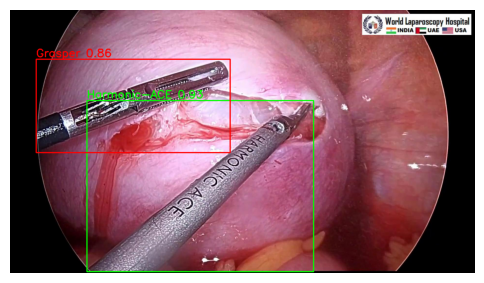

In [50]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

CLASS_LABELS = ["Grasper", "Harmonic-ACE", "Myoma-Screw", "Needle-Holder", "Trocer"]

PRED_COLORS = [
    (0, 0, 255),           # Red - Grasper
    (0, 255, 0),           # Green - Harmonic_Ace
    (255, 0, 0),           # Blue - Myoma_Screw
    (0, 255, 255),         # Yellow - Needle_Holder
    (255, 255, 0)          # Cyan - Trocar
]

# 1. Get original dimensions
orig_h, orig_w = img.shape[:2]
img_with_bbox = img.copy()

# 2. Extract results
# Paddle Output[0] shape is (N, 6) -> [class_id, score, x1, y1, x2, y2]
det_results = outputs[0]

# 3. Filter and Draw
score_thr = 0.5

for res in det_results:
    label_id = int(res[0])
    score = res[1]
    bbox = res[2:] # [x1, y1, x2, y2]

    if score < score_thr:
        continue

    x1, y1, x2, y2 = map(int, bbox)

    # Calculate scale factors
    x1 = int(x1 * orig_w / 640)
    y1 = int(y1 * orig_h / 640)
    x2 = int(x2 * orig_w / 640)
    y2 = int(y2 * orig_h / 640)

    label_text = CLASS_LABELS[label_id] if label_id < len(CLASS_LABELS) else f"ID:{label_id}"
    color = PRED_COLORS[label_id]

    # Draw on the ORIGINAL image
    cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
    cv2.putText(img_with_bbox, f"{label_text} {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

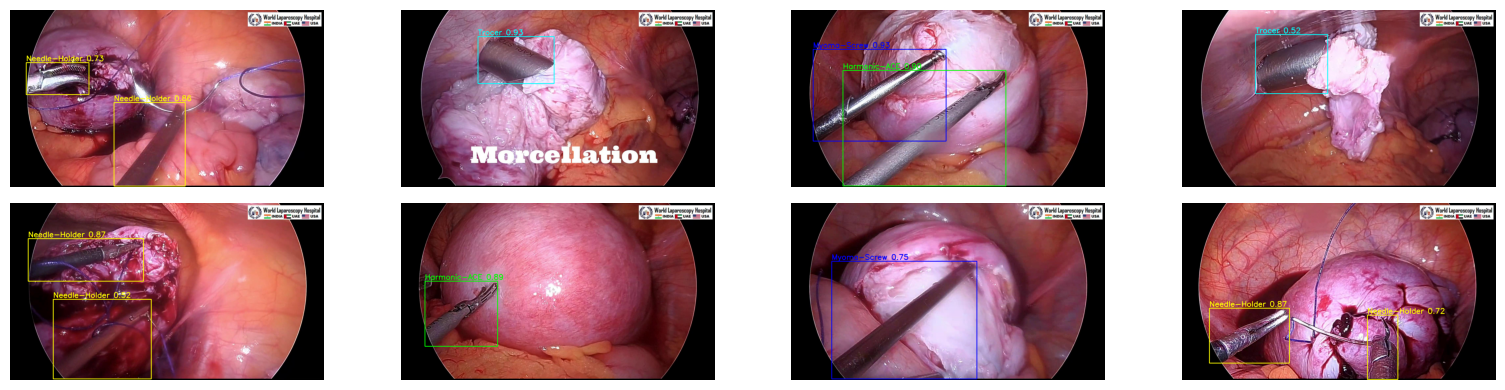

In [51]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/"

CLASS_LABELS = ["Grasper", "Harmonic-ACE", "Myoma-Screw", "Needle-Holder", "Trocer"]

PRED_COLORS = [
    (0, 0, 255),           # Red - Grasper
    (0, 255, 0),           # Green - Harmonic_Ace
    (255, 0, 0),           # Blue - Myoma_Screw
    (0, 255, 255),         # Yellow - Needle_Holder
    (255, 255, 0)          # Cyan - Trocar
]

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    orig_h, orig_w = img.shape[:2]
    img_resized = cv2.resize(img, (640, 640))
    img_input = (img_resized[:, :, ::-1].astype(np.float32)) / 255
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    scale_y = orig_h / 640.0
    scale_x = orig_w / 640.0
    scale_factor_input = np.array([[scale_y, scale_x]], dtype=np.float32)

    im_shape_input = np.array([[orig_h, orig_w]], dtype=np.float32)

    input_feed = {
        "im_shape": im_shape_input,
        "image": img_input,
        "scale_factor": scale_factor_input
    }

    outputs = session.run(None, input_feed)

    img_with_bbox = img.copy()
    det_results = outputs[0]

    score_thr = 0.5

    for res in det_results:
        label_id = int(res[0])
        score = res[1]
        bbox = res[2:] # [x1, y1, x2, y2]

        if score < score_thr:
            continue

        x1, y1, x2, y2 = map(int, bbox)

        # Calculate scale factors
        x1 = int(x1 * orig_w / 640)
        y1 = int(y1 * orig_h / 640)
        x2 = int(x2 * orig_w / 640)
        y2 = int(y2 * orig_h / 640)

        label_text = CLASS_LABELS[label_id] if label_id < len(CLASS_LABELS) else f"ID:{label_id}"
        color = PRED_COLORS[label_id]

        # Draw on the ORIGINAL image
        cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img_with_bbox, f"{label_text} {score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()